# MNIST 손글씨 분류 — 단일 퍼셉트론(SLP)

PyTorch로 가장 단순한 신경망인 **단일 퍼셉트론(Single Layer Perceptron)** 을 만들어 MNIST 손글씨 숫자를 분류합니다. 이후 차시의 MLP/CNN과 비교하기 위한 출발점입니다.

## 학습 목표
- PyTorch의 기본 학습 파이프라인(데이터 로더 → 모델 → 손실 → 옵티마이저 → 학습 루프)을 이해한다.
- `nn.Linear` 한 층만으로 구성된 SLP의 구조와 한계를 파악한다.
- 학습/평가 함수를 분리해 작성하고 `model.train()` / `model.eval()` 모드를 구분해 사용한다.
- 테스트 정확도와 예측 결과를 시각화로 검증한다.

## 사용 라이브러리
- `torch`, `torch.nn`, `torch.optim` — 모델 정의 · 학습
- `torchvision` — MNIST 데이터셋 및 전처리
- `matplotlib`, `numpy` — 이미지/예측 시각화

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 하이퍼파라미터 설정 (SLP·MLP·CNN 공통)

세 모델(SLP·MLP·CNN)의 성능을 **공정하게 비교**하기 위해 학습 변수를 동일하게 맞춥니다.

| 파라미터 | 값 |
| --- | --- |
| `batch_size` | 64 |
| `epochs` | 5 |
| `lr` | 0.001 |
| 옵티마이저 | Adam |
| 손실 함수 | CrossEntropyLoss |

> 같은 데이터 · 같은 학습 변수에서 **모델 구조만** 바꿔가며 정확도를 비교합니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 공통 학습 하이퍼파라미터 (SLP·MLP·CNN 동일) =====
batch_size = 64        # 미니배치 크기
epochs     = 5         # 전체 데이터 반복 횟수
lr         = 0.001     # 학습률 (Adam)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('===== 학습 하이퍼파라미터 =====')
print(f'  batch_size : {batch_size}')
print(f'  epochs     : {epochs}')
print(f'  lr         : {lr}')
print(f'  optimizer  : Adam')
print(f'  loss       : CrossEntropyLoss')
print(f'  device     : {device}')

True
set hyperparameters done


## 데이터 로더 구성

`torchvision.datasets.MNIST`로 학습/테스트 데이터를 받아오고 `DataLoader`로 미니배치 단위 반복자를 만듭니다. `transforms.ToTensor()`는 PIL 이미지를 [0,1] 범위 텐서로 변환합니다.

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

class_names = [str(i) for i in range(10)]

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print('data loading done:', len(train_dataset), 'train /', len(test_dataset), 'test')

data loading done


## 데이터 미리보기

학습 데이터에서 36개 샘플을 그리드 형태로 확인합니다. MNIST는 손글씨 숫자(0~9)로 구성된 균형 잡힌 데이터셋입니다.

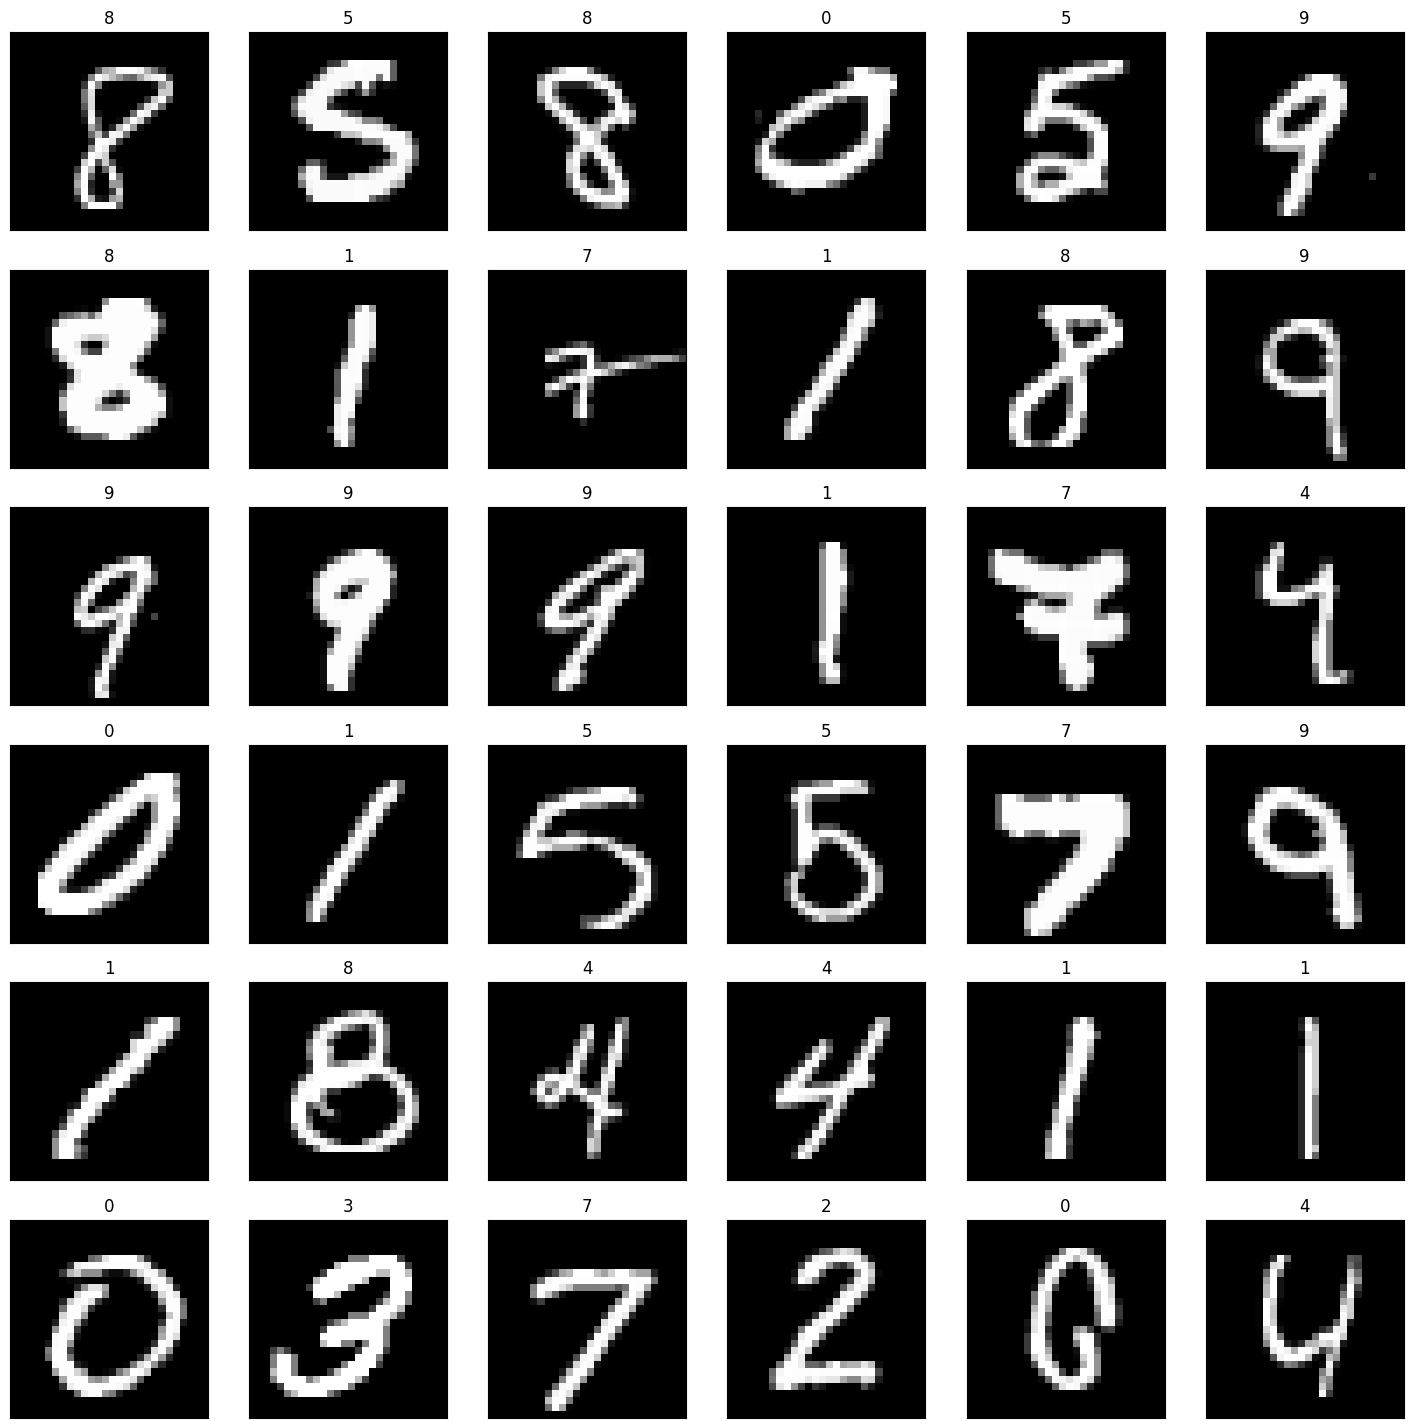

In [4]:
# MNIST 36개 샘플 미리보기
fig = plt.figure(figsize=(18, 18))
for idx in range(36):
    id = np.random.randint(len(train_dataset))
    image, label = train_dataset[id]
    number = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
    number.imshow(image.squeeze().numpy())  # (1, 28, 28) → (28, 28)
    number.set_title(class_names[label])

## 픽셀 단위 시각화

이미지 한 장을 28×28 그리드 위에 픽셀 값과 함께 표시해 신경망이 입력으로 받는 실제 수치를 직관적으로 확인합니다.

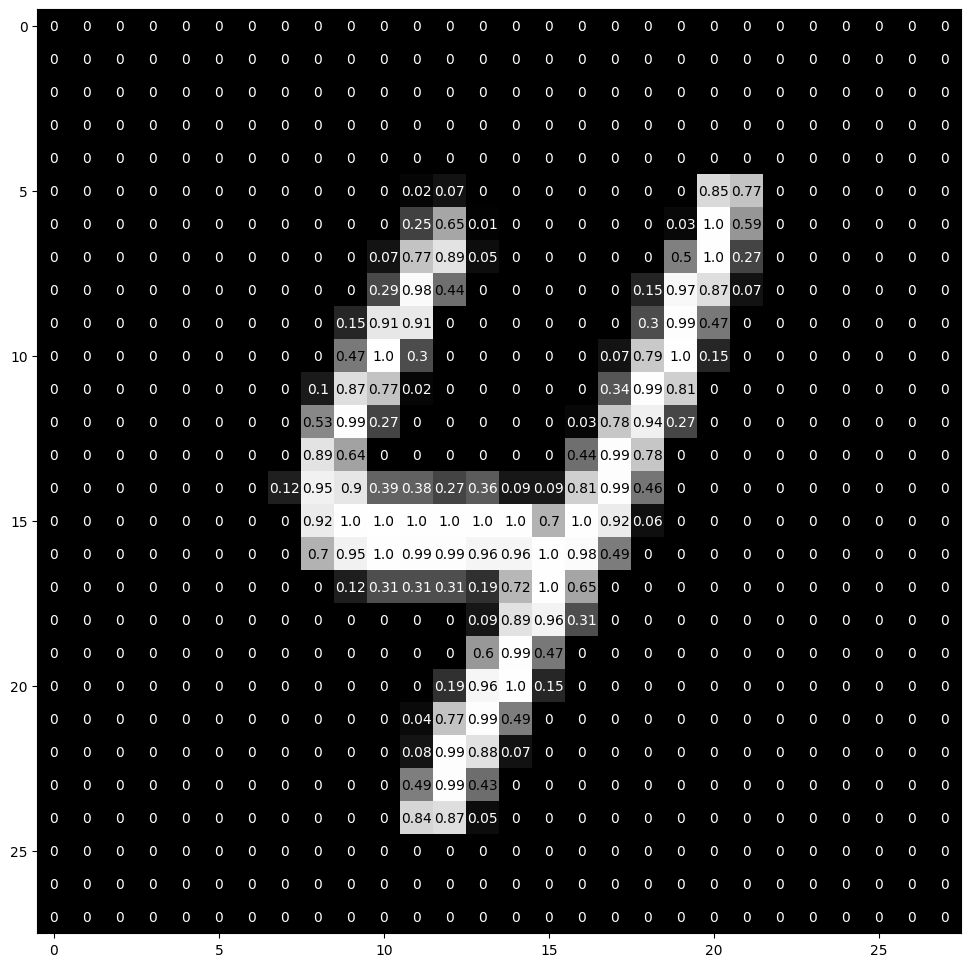

In [5]:
# 이미지 데이터 상세 (픽셀 값 표시)
image, _ = train_dataset[143]
img = image.squeeze().numpy()  # (28, 28)

fig = plt.figure(figsize=(12, 12))
big_number = fig.add_subplot(111)
big_number.imshow(img)
width, height = img.shape
thresh = img.max() / 2.5
for x in range(width):
    for y in range(height):
        val = round(float(img[x][y]), 2) if img[x][y] != 0 else 0
        big_number.annotate(str(val), xy=(y, x),
                            horizontalalignment='center',
                            verticalalignment='center',
                            color='white' if img[x][y] < thresh else 'black')

## SLP 모델 정의

**단일 퍼셉트론(SLP)** 은 입력 784 차원을 곧바로 10개 클래스 점수(logits)로 매핑하는 가장 단순한 신경망입니다.

| 항목 | 값 |
| --- | --- |
| 입력 | 28×28 이미지를 펼친 784 차원 벡터 |
| 출력 | 10개 클래스(0~9) logits |
| 파라미터 수 | 784 × 10 + 10 = 7,850 |
| 은닉층 | 없음 (선형 분류기) |

은닉층이 없어 비선형 패턴을 잡지 못하는 한계를 다음 단계인 **MLP** 에서 은닉층 추가로 해결합니다.

In [6]:
## 모델 설계하기

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 10)

    def forward(self, x):
        x = x.float()
        x = x.view(-1, 784)
        x = self.fc1(x)          # logits 반환 (CrossEntropyLoss 가 softmax 처리)
        return x

model = Net().to(device)
print(model)
print(f'총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}')

model design done


## 모델 인스턴스화 및 옵티마이저 설정

모델을 디바이스로 이동시키고 RMSprop 옵티마이저를 연결합니다. `print(model)`로 출력되는 구조를 보면 SLP가 단 하나의 `Linear(784, 10)` 레이어임을 확인할 수 있습니다.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
print('optimizer = Adam(lr={}), loss = CrossEntropyLoss'.format(lr))

Net(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


## 학습/평가 함수 정의

PyTorch의 표준 학습 루프 패턴입니다.

- `train()`: `model.train()` 모드 → `optimizer.zero_grad()` → 순전파 → 손실 계산 → `loss.backward()` → `optimizer.step()`
- `test()`: `model.eval()` + `torch.no_grad()`로 그라디언트 계산을 끄고 정확도/손실을 누적합니다.

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        out = model(data)
        loss_sum += criterion(out, target).item() * data.size(0)
        correct  += (out.argmax(1) == target).sum().item()
        total    += target.size(0)
    return loss_sum / total, 100.0 * correct / total

## 학습 및 성능 측정

공통 하이퍼파라미터(epochs=5, batch=64, Adam lr=0.001)로 학습하고, 매 epoch마다 테스트셋 **정확도**를 출력합니다. 학습이 끝나면 최종 테스트 정확도를 표시하고 모델을 저장합니다. SLP(선형 분류기)는 은닉층이 없어 MLP/CNN보다 정확도가 낮은 것을 직접 확인할 수 있습니다.

In [9]:
for epoch in range(1, epochs + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    print(f'Epoch {epoch}/{epochs}  train_loss={tr_loss:.4f}  test_loss={te_loss:.4f}  test_acc={te_acc:.2f}%')

# ===== 최종 성능 (정확도) =====
final_loss, final_acc = evaluate(model, test_loader, criterion, device)
print(f'\n[최종 성능] 테스트 정확도: {final_acc:.2f}%')

torch.save(model, './model.pt')

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.331253
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.220003
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.185484
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.961305
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.872327

Test set: Average loss: 0.9619, Accuracy: 7238/10000 (72%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.739920
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.648686
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.202067
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.879234
Train Epoch: 2 [51200/60000 (85%)]	Loss: 1.126670

Test set: Average loss: 0.9657, Accuracy: 7225/10000 (72%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.770493
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.852982
Train Epoch: 3 [25600/60000 (43%)]	Loss: 1.118347
Train Epoch: 3 [38400/60000 (64%)]	Loss: 1.164795
Train Epoch: 3 [51200/60000 (85%)]	Loss: 1.025961

Test set: Average loss: 0.9661, Accuracy: 7245/10000 (72%)

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.914299
Train Epoch: 4 [12800/60000 (21%)]	Lo

## 예측 결과 시각화

테스트 배치에서 36개 샘플을 뽑아 예측값과 정답을 비교합니다. 제목 색상이 **초록**이면 정답, **빨강**이면 오분류입니다. 단일 퍼셉트론은 표현력이 제한적이어서 비슷한 모양의 숫자(예: 4와 9, 3과 8)에서 오류가 자주 발생합니다.

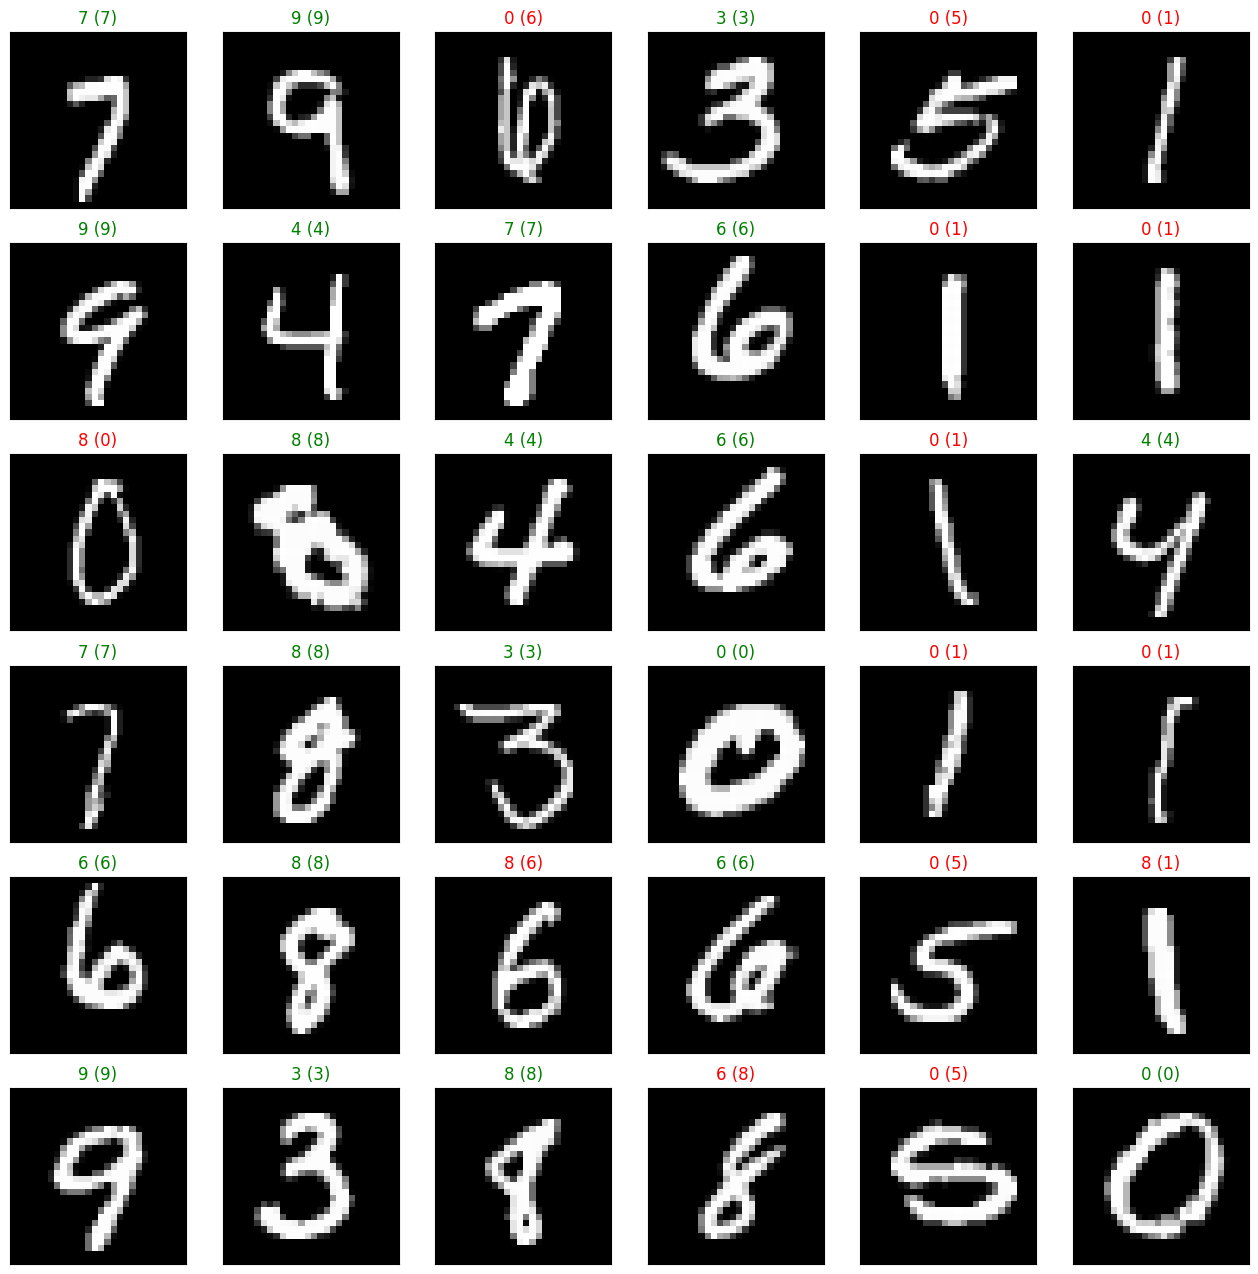

In [10]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)
labels = labels.to(device)

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# 시각화 위해 CPU 로 복귀
preds = preds.cpu()
labels = labels.cpu()
# prep images for display
images = images.cpu().numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(16, 16))
for idx in np.arange(36):
    ax = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))